# **Project 1 Part 1**

Team Members: Chloe Doan and Izzy Kim

# **Gradient Descent**

You must implement a gradient descent optimization algorithm yourself, using Mean Squared Error (MSE) as the objective function. You may use external packages (like NumPy or scikit-learn) for matrix mathematics and feature scaling.

Take careful note of when you are expected to apply your own gradient descent algorithm, and when you should use a pre-defined tool for linear model optimization (eg. scikit-learn.linear_model.LinearRegression)

**1. Imports**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

np.set_printoptions(precision = 4, suppress = True)

**2. Load the data**

In [10]:
df = pd.read_excel("data/concrete+compressive+strength/Concrete_Data.xls")

df.columns = ["cement", "slag", "fly_ash", "water", "superplasticizer", "coarse_agg", "fine_agg", "age", "strength"]
features = list(df.columns[:-1])
target = "strength"

print(df.shape)
df.describe().T

(1030, 9)


,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.165631,104.507142,102.000000,192.375000,272.900000,350.000000,540.000000
slag,1030.0,73.895485,86.279104,0.000000,0.000000,22.000000,142.950000,359.400000
fly_ash,1030.0,54.187136,63.996469,0.000000,0.000000,0.000000,118.270000,200.100000
water,1030.0,181.566359,21.355567,121.750000,164.900000,185.000000,192.000000,247.000000
superplasticizer,1030.0,6.203112,5.973492,0.000000,0.000000,6.350000,10.160000,32.200000
coarse_agg,1030.0,972.918592,77.753818,801.000000,932.000000,968.000000,1029.400000,1145.000000
fine_agg,1030.0,773.578883,80.175427,594.000000,730.950000,779.510000,824.000000,992.600000
age,1030.0,45.662136,63.169912,1.000000,7.000000,28.000000,56.000000,365.000000
strength,1030.0,35.817836,16.705679,2.331808,23.707115,34.442774,46.136287,82.599225


**3. Train/test split and scaling**

In [12]:
TEST_SIZE = 130
SHUFFLE = True
SEED = 42

idx = np.arange(len(df))
if SHUFFLE:
    idx = np.random.default_rng(SEED).permutation(idx)
train_idx, test_idx = idx[:-TEST_SIZE], idx[-TEST_SIZE:]

X_train_raw = df.loc[train_idx, features].to_numpy(dtype = float)
X_test_raw = df.loc[test_idx, features].to_numpy(dtype = float)
y_train = df.loc[train_idx, target].to_numpy(dtype = float)
y_test = df.loc[test_idx, target].to_numpy(dtype = float)

scaler = StandardScaler().fit(X_train_raw)
X_train_std = scaler.transform(X_train_raw)
X_test_std = scaler.transform(X_test_raw)

print("train:", X_train_raw.shape, " test:", X_test_raw.shape)

train: (900, 8)  test: (130, 8)


**4. Metrics**

In [13]:
def mse(y, y_hat):
    return np.mean((y - y_hat) ** 2)

def r2(y, y_hat):
    return 1 - mse(y, y_hat) / np.var(y)

**5. Gradient Descent**

In [14]:
def add_bias(X):
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:                      
        X = X.reshape(-1, 1)
    return np.column_stack([np.ones(len(X)), X])

def predict(X, theta):
    return add_bias(X) @ theta

def gradient_descent(X, y, lr=0.01, n_iters=10_000, tol=1e-10, adaptive=False, theta0=None):
    Xb = add_bias(X)
    n, k = Xb.shape
    theta = np.zeros(k) if theta0 is None else np.asarray(theta0, dtype=float).copy()

    loss = np.mean((Xb @ theta - y) ** 2)
    history = [loss]
    status = "max_iters"

    for _ in range(n_iters):
        grad = (2 / n) * Xb.T @ (Xb @ theta - y)
        new_theta = theta - lr * grad
        with np.errstate(over="ignore", invalid="ignore"):   
            new_loss = np.mean((Xb @ new_theta - y) ** 2)

        if not np.isfinite(new_loss):
            status = "diverged"
            break

        if adaptive:
            if new_loss > loss:         
                lr *= 0.5
                continue
            lr *= 1.05                  

        improvement = loss - new_loss
        theta, loss = new_theta, new_loss
        history.append(loss)

        if adaptive and improvement < tol:
            status = "converged"
            break
        if not adaptive and abs(improvement) < tol:
            status = "converged"
            break

    return theta, {"loss": np.array(history), "status": status, "final_lr": lr}

def evaluate(theta, X_tr, y_tr, X_te, y_te):
    p_tr, p_te = predict(X_tr, theta), predict(X_te, theta)
    return {"train_MSE": mse(y_tr, p_tr), "train_R2": r2(y_tr, p_tr),
            "test_MSE":  mse(y_te, p_te), "test_R2":  r2(y_te, p_te)}

**6. Learning-rate**

/opt/miniconda3/lib/python3.13/site-packages/matplotlib/scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


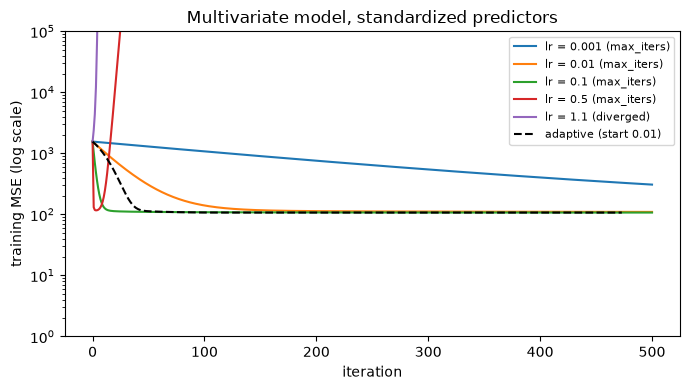

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
for lr in [0.001, 0.01, 0.1, 0.5, 1.1]:
    _, info = gradient_descent(X_train_std, y_train, lr=lr, n_iters=500, tol=0)
    ax.plot(info["loss"], label=f"lr = {lr} ({info['status']})")
_, info = gradient_descent(X_train_std, y_train, lr=0.01, n_iters=500, tol=0, adaptive=True)
ax.plot(info["loss"], "k--", label="adaptive (start 0.01)")

ax.set_yscale("log"); ax.set_ylim(top=1e5)
ax.set_xlabel("iteration"); ax.set_ylabel("training MSE (log scale)")
ax.set_title("Multivariate model, standardized predictors")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

**7. Univariate Models, one per predictor**

In [16]:
rows = []
for j, name in enumerate(features):
    theta, info = gradient_descent(X_train_std[:, j], y_train, lr=0.1)
    m_orig = theta[1] / scaler.scale_[j]
    b_orig = theta[0] - theta[1] * scaler.mean_[j] / scaler.scale_[j]
    rows.append({"feature": name, "m (std)": theta[1], "b (std)": theta[0],
                 "m (orig units)": m_orig, "b (orig units)": b_orig,
                 **evaluate(theta, X_train_std[:, j], y_train, X_test_std[:, j], y_test),
                 "iters": len(info["loss"]) - 1, "status": info["status"]})

uni_results = pd.DataFrame(rows).set_index("feature")
uni_results.round(4)

,m (std),b (std),m (orig units),b (orig units),train_MSE,train_R2,test_MSE,test_R2,iters,status
feature,,,,,,,,,,
cement,8.2337,35.8218,0.0792,13.6251,210.1807,0.2439,206.5030,0.2744,67,converged
slag,2.2498,35.8218,0.0262,33.8733,272.9135,0.0182,279.4685,0.0180,67,converged
fly_ash,-1.8958,35.8218,-0.0296,37.4443,274.3810,0.0129,284.8870,-0.0011,67,converged
water,-4.9296,35.8218,-0.2315,77.8585,253.6740,0.0874,267.6237,0.0596,67,converged
superplasticizer,6.2675,35.8218,1.0531,29.1913,238.6935,0.1413,260.7640,0.0837,67,converged
coarse_agg,-2.5774,35.8218,-0.0329,67.8438,271.3320,0.0239,270.7857,0.0485,67,converged
fine_agg,-2.6784,35.8218,-0.0332,61.4577,270.8013,0.0258,272.6004,0.0421,67,converged
age,5.5298,35.8218,0.0897,31.7744,247.3964,0.1100,257.6153,0.0948,67,converged


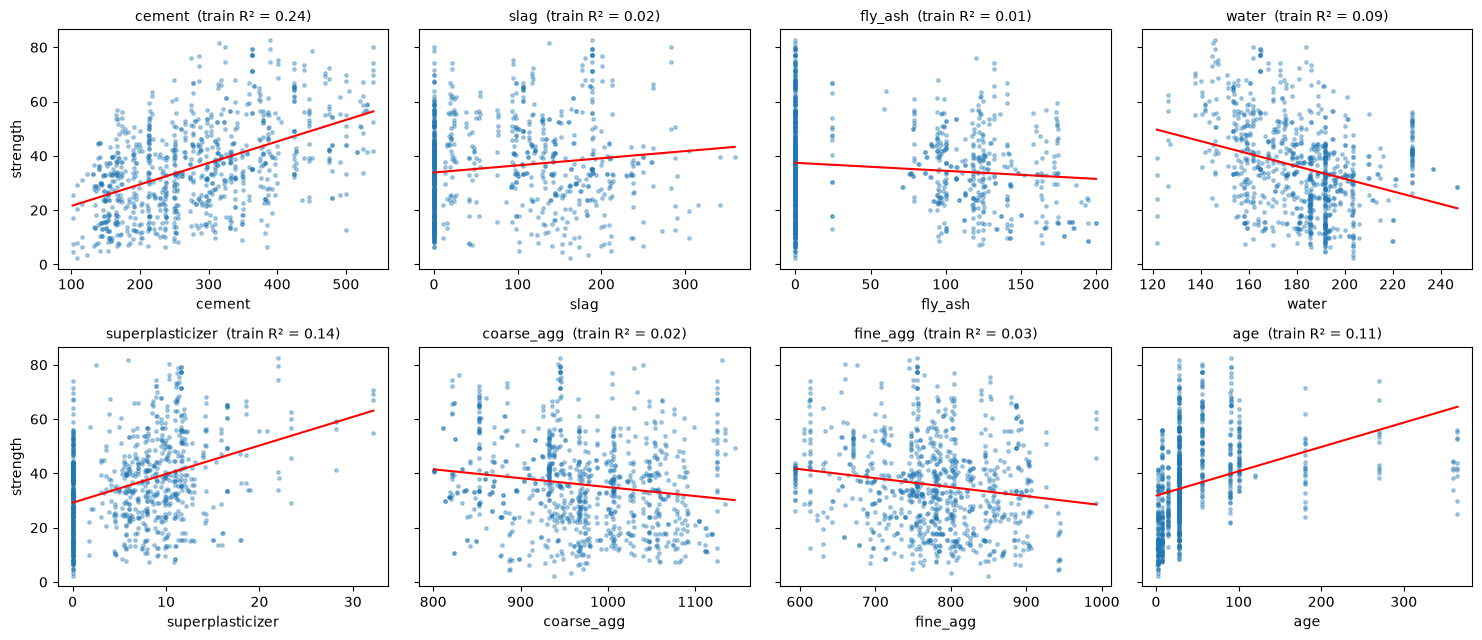

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharey=True)
for ax, (j, name) in zip(axes.ravel(), enumerate(features)):
    x = X_train_raw[:, j]
    ax.scatter(x, y_train, s=6, alpha=0.35)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, uni_results.loc[name, "m (orig units)"] * xs + uni_results.loc[name, "b (orig units)"], "r")
    ax.set_title(f"{name}  (train R² = {uni_results.loc[name, 'train_R2']:.2f})", fontsize=10)
    ax.set_xlabel(name)
axes[0, 0].set_ylabel("strength"); axes[1, 0].set_ylabel("strength")
plt.tight_layout(); plt.show()

**8. Multivariate model, all 8 predictors standardized**

In [18]:
theta_multi, info_multi = gradient_descent(X_train_std, y_train, lr=0.1, n_iters=50_000)
print(info_multi["status"], "after", len(info_multi["loss"]) - 1, "iterations")

display(pd.Series(theta_multi, index=["intercept"] + features, name="theta (std units)").round(4))
pd.Series(evaluate(theta_multi, X_train_std, y_train, X_test_std, y_test)).round(4)

converged after 1708 iterations


intercept           35.8218
cement              12.5866
slag                 9.0754
fly_ash              5.7498
water               -2.8145
superplasticizer     2.0969
coarse_agg           1.5577
fine_agg             1.7789
age                  7.1103
Name: theta (std units), dtype: float64

train_MSE    107.2671
train_R2       0.6141
test_MSE     107.4482
test_R2        0.6224
dtype: float64

**10. Raw (unscaled) predictors**

In [19]:
_, info = gradient_descent(X_train_raw, y_train, lr=0.01, n_iters=1000)
print("lr = 0.01 on raw data ->", info["status"], "after", len(info["loss"]) - 1, "iterations")

theta_raw_fixed, info_fixed = gradient_descent(X_train_raw, y_train, lr=1e-7, n_iters=100_000, tol=0)
theta_raw_adapt, info_adapt = gradient_descent(X_train_raw, y_train, lr=1e-7, n_iters=100_000, tol=0, adaptive=True)

raw_results = pd.DataFrame({
    "raw, fixed lr=1e-7":  evaluate(theta_raw_fixed, X_train_raw, y_train, X_test_raw, y_test),
    "raw, adaptive":       evaluate(theta_raw_adapt, X_train_raw, y_train, X_test_raw, y_test),
    "standardized":        evaluate(theta_multi, X_train_std, y_train, X_test_std, y_test),
}).T
raw_results.round(4)

lr = 0.01 on raw data -> diverged after 33 iterations


,train_MSE,train_R2,test_MSE,test_R2
"raw, fixed lr=1e-7",108.0377,0.6113,105.2601,0.6301
"raw, adaptive",107.4519,0.6134,106.4202,0.6260
standardized,107.2671,0.6141,107.4482,0.6224


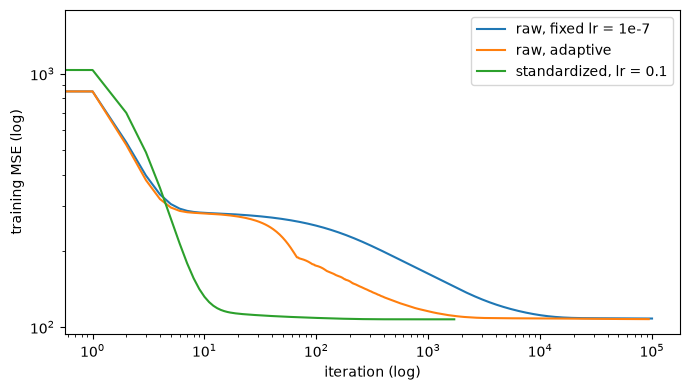

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(info_fixed["loss"], label="raw, fixed lr = 1e-7")
plt.plot(info_adapt["loss"], label="raw, adaptive")
plt.plot(info_multi["loss"], label="standardized, lr = 0.1")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("iteration (log)"); plt.ylabel("training MSE (log)")
plt.legend(); plt.tight_layout(); plt.show()

**11. Reference solution with scikit-learn**

In [21]:
sk_multi = LinearRegression().fit(X_train_raw, y_train)
theta_sk = np.r_[sk_multi.intercept_, sk_multi.coef_]

# Convert the standardized GD solution back to original units for a like-for-like comparison
m_orig = theta_multi[1:] / scaler.scale_
b_orig = theta_multi[0] - np.sum(theta_multi[1:] * scaler.mean_ / scaler.scale_)

display(pd.DataFrame({"sklearn": theta_sk,
                      "GD (std -> orig units)": np.r_[b_orig, m_orig],
                      "GD raw adaptive": theta_raw_adapt},
                     index=["intercept"] + features).round(4))

pd.concat([raw_results,
           pd.DataFrame({"sklearn LinearRegression":
                         evaluate(theta_sk, X_train_raw, y_train, X_test_raw, y_test)}).T]).round(4)

,sklearn,GD (std -> orig units),GD raw adaptive
intercept,-30.7006,-30.6934,-0.0004
cement,0.1211,0.1211,0.1140
slag,0.1058,0.1058,0.0976
fly_ash,0.0897,0.0897,0.0813
water,-0.1322,-0.1322,-0.1808
superplasticizer,0.3523,0.3523,0.2615
coarse_agg,0.0199,0.0199,0.0095
fine_agg,0.0220,0.0220,0.0115
age,0.1154,0.1154,0.1153


,train_MSE,train_R2,test_MSE,test_R2
"raw, fixed lr=1e-7",108.0377,0.6113,105.2601,0.6301
"raw, adaptive",107.4519,0.6134,106.4202,0.6260
standardized,107.2671,0.6141,107.4482,0.6224
sklearn LinearRegression,107.2671,0.6141,107.4483,0.6224


# **Data Analysis**

Use your implemented algorithm, a third-part linear model optimization tool (eg. scikit-learn.linear_model.LinearRegression), and a third-party statistical tool (e.g.,statsmodels.api.OLS) to explicitly answer the following questions.

,untransformed,standardized
learning rate used,2.9948e-07,0.219922
largest stable learning rate,5.9896e-07,0.439844
condition number,1.11841e+10,77.5425
iterations to R2 > 0,7,2
iterations to within 1% of optimal MSE,"9,840",55
iterations run,"200,000","200,000"
final train MSE,107.456,107.267
final train R2,0.613433,0.614112


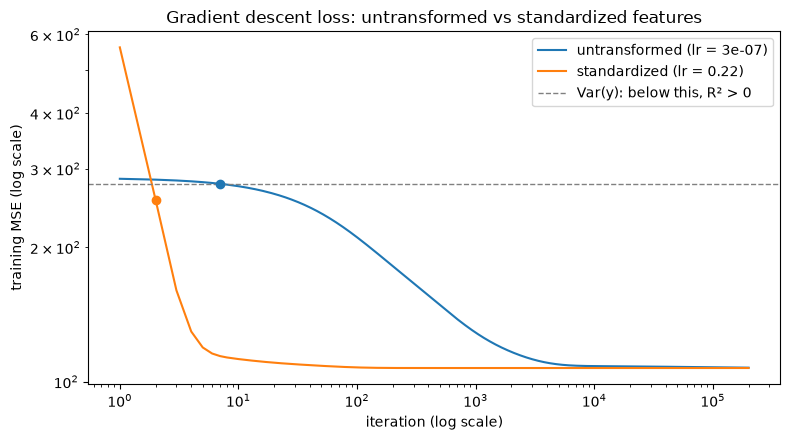

lr = 0.22 on untransformed features -> diverged after 25 iterations


In [22]:
import statsmodels.api as sm

def hessian_eigs(X):
    Xb = add_bias(X)
    return np.linalg.eigvalsh((2 / len(Xb)) * Xb.T @ Xb)      

def iters_to_positive_r2(loss_history, y):
    hit = np.where(loss_history < np.var(y))[0]
    return int(hit[0]) if len(hit) else None

def first_below(loss_history, level):
    hit = np.where(loss_history <= level)[0]
    return int(hit[0]) if len(hit) else None

best_mse = mse(y_train, LinearRegression().fit(X_train_raw, y_train).predict(X_train_raw))

runs = {}
for label, X in [("untransformed", X_train_raw), ("standardized", X_train_std)]:
    eig = hessian_eigs(X)
    lr = 1 / eig[-1]                       
    theta, info = gradient_descent(X, y_train, lr=lr, n_iters=200_000, tol=0)
    runs[label] = dict(theta=theta, loss=info["loss"], lr=lr,
                       cond=eig[-1] / eig[0], max_lr=2 / eig[-1],
                       hit=iters_to_positive_r2(info["loss"], y_train),
                       near=first_below(info["loss"], 1.01 * best_mse))

summary = pd.DataFrame({
    k: {"learning rate used": r["lr"],
        "largest stable learning rate": r["max_lr"],
        "condition number": r["cond"],
        "iterations to R2 > 0": r["hit"],
        "iterations to within 1% of optimal MSE": r["near"],
        "iterations run": len(r["loss"]) - 1,
        "final train MSE": r["loss"][-1],
        "final train R2": 1 - r["loss"][-1] / np.var(y_train)}
    for k, r in runs.items()})
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
display(summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
for label, r in runs.items():
    it = np.arange(len(r["loss"]))
    line, = ax.plot(it[1:], r["loss"][1:], label=f"{label} (lr = {r['lr']:.2g})")
    if r["hit"]:
        ax.scatter(r["hit"], r["loss"][r["hit"]], color=line.get_color(), zorder=3)
ax.axhline(np.var(y_train), color="gray", ls="--", lw=1, label="Var(y): below this, R² > 0")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("iteration (log scale)"); ax.set_ylabel("training MSE (log scale)")
ax.set_title("Gradient descent loss: untransformed vs standardized features")
ax.legend(); plt.tight_layout(); plt.show()

_, bad = gradient_descent(X_train_raw, y_train, lr=runs["standardized"]["lr"], n_iters=1000)
print(f"lr = {runs['standardized']['lr']:.3g} on untransformed features -> "
      f"{bad['status']} after {len(bad['loss'])-1} iterations")

In [23]:
sk_raw = LinearRegression().fit(X_train_raw, y_train)
sk_std = LinearRegression().fit(X_train_std, y_train)

ols_raw = sm.OLS(y_train, sm.add_constant(X_train_raw)).fit()
ols_std = sm.OLS(y_train, sm.add_constant(X_train_std)).fit()

names = ["intercept"] + features
coef = pd.DataFrame({
    "raw coef":            np.r_[sk_raw.intercept_, sk_raw.coef_],
    "scaled coef":         np.r_[sk_std.intercept_, sk_std.coef_],
    "scaled -> raw units": np.r_[sk_std.intercept_ - np.sum(sk_std.coef_ * scaler.mean_ / scaler.scale_),
                                 sk_std.coef_ / scaler.scale_],
    "t (raw)": ols_raw.tvalues, "t (scaled)": ols_std.tvalues,
    "p (raw)": ols_raw.pvalues, "p (scaled)": ols_std.pvalues,
}, index=names)
display(coef)

fit = pd.DataFrame({
    "raw":    {"train MSE": mse(y_train, sk_raw.predict(X_train_raw)), "train R2": r2(y_train, sk_raw.predict(X_train_raw)),
               "test MSE":  mse(y_test,  sk_raw.predict(X_test_raw)),  "test R2":  r2(y_test,  sk_raw.predict(X_test_raw)),
               "statsmodels R2": ols_raw.rsquared},
    "scaled": {"train MSE": mse(y_train, sk_std.predict(X_train_std)), "train R2": r2(y_train, sk_std.predict(X_train_std)),
               "test MSE":  mse(y_test,  sk_std.predict(X_test_std)),  "test R2":  r2(y_test,  sk_std.predict(X_test_std)),
               "statsmodels R2": ols_std.rsquared}})
display(fit)

print("largest difference between raw-model and scaled-model predictions (test):",
      np.max(np.abs(sk_raw.predict(X_test_raw) - sk_std.predict(X_test_std))))
print("sklearn vs statsmodels, largest coefficient difference:",
      np.max(np.abs(np.r_[sk_raw.intercept_, sk_raw.coef_] - ols_raw.params)))

,raw coef,scaled coef,scaled -> raw units,t (raw),t (scaled),p (raw),p (scaled)
intercept,-30.7006,35.8218,-30.7006,-1.08107,103.241,0.279957,0
cement,0.12106,12.5869,0.12106,12.9185,12.9185,4.05495e-35,4.05495e-35
slag,0.105822,9.0756,0.105822,9.63035,9.63035,5.98035e-21,5.98035e-21
fly_ash,0.0896908,5.75005,0.0896908,6.42231,6.42231,2.18107e-10,2.18107e-10
water,-0.132172,-2.81428,-0.132172,-3.08751,-3.08751,0.00208091,0.00208091
superplasticizer,0.352346,2.09693,0.352346,3.50366,3.50366,0.000481744,0.000481744
coarse_agg,0.019899,1.55793,0.019899,1.99916,1.99916,0.045894,0.045894
fine_agg,0.0220324,1.77914,0.0220324,1.92454,1.92454,0.0546046,0.0546046
age,0.115385,7.11031,0.115385,19.4753,19.4753,1.17636e-70,1.17636e-70


,raw,scaled
train MSE,107.267,107.267
train R2,0.614112,0.614112
test MSE,107.448,107.448
test R2,0.622433,0.622433
statsmodels R2,0.614112,0.614112


largest difference between raw-model and scaled-model predictions (test): 6.394884621840902e-14
sklearn vs statsmodels, largest coefficient difference: 5.258016244624741e-13


**1. How does features scaling affect convergence speed and stability?**

**Response:** Scaling makes gradient descent far faster and far more stable. From the 'Gradient Descent Loss' plot, we can see that both models reach a positive R-squared almost immediately. The dashed line is Var(y), about 278. Standardized crosses it at iteration 2 and untransformed at about iteration 7 (the two dots). After that, the two behave very differently. Standardized is essentially at its floor (MSE about 108) within roughly 100 iterations. Untransformed needs on the order of 10,000 iterations to get to the same level, so it is about 100 times slower. Both flatten at an MSE of about 108, which is an R-squared of roughly 1 - 108/278 = 0.61. That supports the idea that scaling changes how fast you get there, not where you end up The learning rates differ by about six orders of magnitude (3e-7 against 0.22). That is the stability point that the raw features force a tiny step size.
Why standardizing fixes it is because every feature gets mean 0 and variance 1, so the Hessian becomes roughly the correlation matrix. Its eigenvalues are all near 1, the loss surface is close to round, and one learning rate suits every direction. Centering also makes the intercept independent of the slopes.

**2. Does a linear transformation meaningfully change the optimal solution?**

**Response:** No. The coefficients change, but the fitted model is the same. From the second cell of Data Analysis block, we can see that train and test MSE and R-squared are identical for the raw and scaled models, and their predictions differ only by floating-point error. Each scaled slope equals the raw slope times that feature's standard deviation, and the scaled intercept becomes the mean of y. The `scaled -> raw units` column converts back and matches the raw coefficients exactly. Statsmodels gives identical t-statistics and p-values for every slope. Only the intercept's t-statistic changes, because it now tests a different quantity (strength at average inputs rather than at all-zero inputs).